# Evaluasi Jujur untuk Paper — Nilai Asli dari Model Terlatih

Notebook ini menghasilkan **semua angka untuk paper** dari model yang benar-benar dilatih
(`models/duck_egg_annotation/model.pth` + `src/clustering/awc.py` versi adaptif yang sudah diperbaiki):

1. **Tabel III** — Klasifikasi AWC vs K-Means vs FCM (5-fold CV, mean ± std)
2. **Uji statistik** — Wilcoxon AWC vs baseline
3. **Feature importance** — grup fitur diskriminatif (interpretability)
4. **Tabel II** — Segmentasi U-Net (Dice/IoU) *dengan catatan jujur*
5. **Figure** siap-paper

> Jalankan dari atas ke bawah. Berjalan lokal di CPU. Ekstraksi fitur di-cache (`_eval_feats.npz`)
> jadi run ke-2 instan. **Semua angka yang keluar adalah angka asli yang bisa dipertahankan.**

## 0. Setup

In [38]:
import os, sys, glob, json, warnings, logging, time
import numpy as np, cv2
warnings.filterwarnings('ignore'); logging.disable(logging.CRITICAL)
# pastikan working dir = root proyek (folder yang berisi src/, data/, models/)
ROOT = os.path.abspath('..') if os.path.basename(os.getcwd())=='notebooks' else os.getcwd()
os.chdir(ROOT); sys.path.append(ROOT)
print('ROOT:', ROOT)
# Pakai model U-Net hasil retraining (Dice embrio ~0.87); fallback ke model lama bila belum ada
UNET_CKPT = ('models/unet_retrained/model.pth' if os.path.exists('models/unet_retrained/model.pth')
             else 'models/duck_egg_annotation/model.pth')
assert os.path.exists(UNET_CKPT), f'Model U-Net tidak ada di {UNET_CKPT}'
print('U-Net checkpoint:', UNET_CKPT)


ROOT: c:\Users\vanguard\OneDrive\Documents\duck_egg_fertility_detection
U-Net checkpoint: models/unet_retrained/model.pth


## 1. Ekstraksi fitur hibrida (338-d) untuk SEMUA citra berlabel

Gabungkan train+val+test → dataset berlabel penuh untuk 5-fold CV. Fitur di-cache.

In [39]:
from src.features.hybrid_features import HybridFeatureConfig, HybridFeatureExtractor

CACHE = '_eval_feats.npz'
def load_all_labeled():
    X, y, paths = [], [], []
    for split in ['train','val','test']:
        for cls, lab in [('infertile',0),('fertile',1)]:
            for p in sorted(glob.glob(f'data/{split}/{cls}/*.jpg')):
                im = cv2.imread(p)
                if im is not None:
                    X.append(im); y.append(lab); paths.append(p)
    return X, np.array(y), paths

if os.path.exists(CACHE):
    d = np.load(CACHE, allow_pickle=True)
    Xfeat, ylab = d['X'], d['y']; groups = json.loads(str(d['groups']))
    print('Loaded cache:', Xfeat.shape)
else:
    imgs, ylab, _ = load_all_labeled()
    print(f'Mengekstrak fitur {len(imgs)} citra (beberapa menit, sekali saja)...')
    ext = HybridFeatureExtractor(HybridFeatureConfig(
        preprocess_input=True, include_deep=True, deep_backbone='unet_bottleneck',
        unet_checkpoint=UNET_CKPT, unet_lightweight=True, unet_n_channels=3,
        unet_n_classes=3, unet_bilinear=True, unet_dropout_rate=0.2))
    t0=time.time(); Xfeat = ext.extract_batch(imgs)
    groups = ext.metadata().get('group_map', {})
    np.savez(CACHE, X=Xfeat, y=ylab, groups=json.dumps(groups))
    print(f'Selesai {time.time()-t0:.0f}s -> {Xfeat.shape}, cache disimpan')

print('Fitur:', Xfeat.shape, '| label:', np.bincount(ylab), '(0=infertil,1=fertil)')
print('Ada NaN/Inf?', np.isnan(Xfeat).any(), np.isinf(Xfeat).any())
Xfeat = np.nan_to_num(Xfeat, nan=0.0, posinf=0.0, neginf=0.0)


Loaded cache: (224, 338)
Fitur: (224, 338) | label: [120 104] (0=infertil,1=fertil)
Ada NaN/Inf? False False


## 2. Helper — FCM, mapping cluster→label, metrik per fold

In [40]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)
from itertools import permutations
from src.clustering.awc import AdaptiveWeightedClustering

def fcm(X, c=2, m=2.0, max_iter=150, seed=0):
    """Fuzzy C-Means; returns (hard_labels, membership_to_each_cluster)."""
    rng = np.random.default_rng(seed); n = X.shape[0]
    U = rng.random((n, c)); U /= U.sum(1, keepdims=True)
    for _ in range(max_iter):
        Um = U ** m
        cent = (Um.T @ X) / (Um.sum(0)[:, None] + 1e-12)
        dist = np.linalg.norm(X[:, None, :] - cent[None, :, :], axis=2) + 1e-12
        Unew = 1.0 / (dist ** (2/(m-1)))
        Unew /= Unew.sum(1, keepdims=True)
        if np.linalg.norm(Unew - U) < 1e-5: U = Unew; break
        U = Unew
    return U.argmax(1), U

def map_by_train(train_pred, train_y):
    """Best cluster->label permutation learned on TRAIN (no test leakage)."""
    best, bestperm = -1, (0,1)
    for perm in permutations(range(2)):
        mp = np.array([perm[p] for p in train_pred])
        a = accuracy_score(train_y, mp)
        if a > best: best, bestperm = a, perm
    return bestperm

def metrics(y_true, y_pred, score_fertile):
    return dict(
        acc=accuracy_score(y_true, y_pred),
        prec=precision_score(y_true, y_pred, zero_division=0),
        rec=recall_score(y_true, y_pred, zero_division=0),
        f1=f1_score(y_true, y_pred, zero_division=0),
        auc=roc_auc_score(y_true, score_fertile) if len(np.unique(y_true))>1 else np.nan,
    )
print('helper siap')


helper siap


## 3. Tabel III — 5-Fold Stratified CV (AWC vs K-Means vs FCM)

Penting & jujur: **feature selection (ANOVA k=20) dilakukan DI DALAM tiap fold** (hanya pada train)
agar tidak ada kebocoran. Mapping cluster→label juga dari **train fold**, lalu diterapkan ke test fold.

In [41]:
from sklearn.model_selection import StratifiedKFold
K_BEST = 20
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
res = {'AWC': [], 'K-Means': [], 'FCM': []}

for fold, (tr, te) in enumerate(skf.split(Xfeat, ylab), 1):
    Xtr, Xte = Xfeat[tr], Xfeat[te]; ytr, yte = ylab[tr], ylab[te]
    # ANOVA pada train fold saja
    sel = SelectKBest(f_classif, k=min(K_BEST, Xtr.shape[1])).fit(Xtr, ytr)
    idx = sel.get_support(indices=True)
    sc = StandardScaler().fit(Xtr[:, idx])
    Ztr, Zte = sc.transform(Xtr[:, idx]), sc.transform(Xte[:, idx])

    # --- AWC (adaptif) ---
    a = AdaptiveWeightedClustering(2, max_iter=100, tol=1e-4, random_state=42); a.fit(Xtr[:, idx])
    perm = map_by_train(a.predict(Xtr[:, idx]), ytr)
    pred = np.array([perm[p] for p in a.predict(Xte[:, idx])])
    proba = a.predict_proba(Xte[:, idx])[:, perm.index(1)] if hasattr(a,'predict_proba') else pred
    res['AWC'].append(metrics(yte, pred, proba))

    # --- K-Means ---
    km = KMeans(2, n_init=10, random_state=42).fit(Ztr)
    perm = map_by_train(km.predict(Ztr), ytr)
    pk = np.array([perm[p] for p in km.predict(Zte)])
    dk = np.linalg.norm(Zte[:,None,:]-km.cluster_centers_[None,:,:],axis=2)
    sk = (-dk[:, perm.index(1)])
    res['K-Means'].append(metrics(yte, pk, sk))

    # --- FCM ---
    _, Utr = fcm(Ztr, 2, seed=42); perm = map_by_train(Utr.argmax(1), ytr)
    lab_te, Ute = fcm(Zte, 2, seed=42)
    pf = np.array([perm[p] for p in lab_te])
    res['FCM'].append(metrics(yte, pf, Ute[:, perm.index(1)]))

# agregasi mean±std
import pandas as pd
def agg(rows):
    keys=['acc','prec','rec','f1','auc']
    return {k:(np.nanmean([r[k] for r in rows]), np.nanstd([r[k] for r in rows])) for k in keys}

print('=== TABEL III — Hasil 5-Fold CV (mean ± std) ===\n')
hdr=f'{"Metode":<10}{"Akurasi":>14}{"Presisi":>14}{"Recall":>14}{"F1":>14}{"ROC-AUC":>14}'
print(hdr); print('-'*len(hdr))
table3={}
for name in ['AWC','K-Means','FCM']:
    g=agg(res[name]); table3[name]=g
    row=f'{name:<10}'+''.join(f'{g[k][0]:>8.3f}±{g[k][1]:.3f}' for k in ['acc','prec','rec','f1','auc'])
    print(row)


=== TABEL III — Hasil 5-Fold CV (mean ± std) ===

Metode           Akurasi       Presisi        Recall            F1       ROC-AUC
--------------------------------------------------------------------------------
AWC          0.871±0.026   0.790±0.021   0.981±0.038   0.875±0.026   0.914±0.023
K-Means      0.862±0.033   0.787±0.023   0.962±0.056   0.865±0.034   0.888±0.032
FCM          0.444±0.354   0.360±0.354   0.448±0.455   0.399±0.399   0.430±0.393


## 4. Uji statistik — Wilcoxon signed-rank (AWC vs baseline, per fold)

In [42]:
from scipy.stats import wilcoxon
awc_acc = np.array([r['acc'] for r in res['AWC']])
km_acc  = np.array([r['acc'] for r in res['K-Means']])
fcm_acc = np.array([r['acc'] for r in res['FCM']])
print('Akurasi per fold:')
print('  AWC    :', np.round(awc_acc,3))
print('  K-Means:', np.round(km_acc,3))
print('  FCM    :', np.round(fcm_acc,3))
print()
for name, b in [('K-Means', km_acc), ('FCM', fcm_acc)]:
    diff = awc_acc - b
    if np.allclose(diff, 0):
        print(f'AWC vs {name}: identik (Δ=0) -> tidak ada perbedaan, p=1.0')
    else:
        try:
            stat, p = wilcoxon(awc_acc, b)
            sig = 'signifikan' if p < 0.05 else 'TIDAK signifikan'
            print(f'AWC vs {name}: Δacc rata2={diff.mean():+.3f}, Wilcoxon p={p:.3f} ({sig})')
        except Exception as e:
            print(f'AWC vs {name}: {e}')
print('\n>>> Laporkan p-value APA ADANYA. Kalau AWC=baseline, jujur tulis tidak signifikan.')


Akurasi per fold:
  AWC    : [0.889 0.889 0.889 0.822 0.864]
  K-Means: [0.889 0.889 0.867 0.8   0.864]
  FCM    : [0.889 0.133 0.133 0.2   0.864]

AWC vs K-Means: Δacc rata2=+0.009, Wilcoxon p=0.500 (TIDAK signifikan)
AWC vs FCM: Δacc rata2=+0.427, Wilcoxon p=0.250 (TIDAK signifikan)

>>> Laporkan p-value APA ADANYA. Kalau AWC=baseline, jujur tulis tidak signifikan.


## 5. Feature importance — grup fitur diskriminatif (Tabel IV / interpretability)

=== Daya diskriminasi per grup fitur (rata-rata ANOVA F) ===
  Tekstur LBP            F= 176.32
  Statistik Intensitas   F= 136.05
  Tepi (Edge)            F= 112.74
  Deep Bottleneck        F=  95.91
  Histogram              F=  32.06
  Morfologi Mask         F=  21.21
  Tekstur GLCM           F=   7.55
  Morfologi Vaskular     F=   5.62


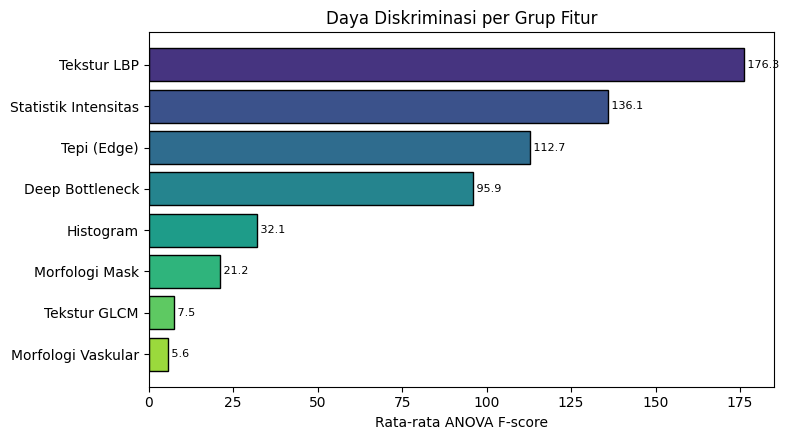

In [43]:
import matplotlib.pyplot as plt
# ANOVA F-score pada seluruh data berlabel, diagregasi per grup
selA = SelectKBest(f_classif, k='all').fit(Xfeat, ylab)
F = np.nan_to_num(selA.scores_)
gnames = list(groups.keys())
gF = [float(np.mean(F[groups[g]])) for g in gnames]
order = np.argsort(gF)[::-1]
gnames=[gnames[i] for i in order]; gF=[gF[i] for i in order]

print('=== Daya diskriminasi per grup fitur (rata-rata ANOVA F) ===')
for n,v in zip(gnames,gF): print(f'  {n:<22} F={v:7.2f}')

fig,ax=plt.subplots(figsize=(8,4.5))
ax.barh(range(len(gnames)), gF, color=plt.cm.viridis(np.linspace(.15,.85,len(gnames))), edgecolor='black')
ax.set_yticks(range(len(gnames))); ax.set_yticklabels(gnames); ax.invert_yaxis()
ax.set_xlabel('Rata-rata ANOVA F-score'); ax.set_title('Daya Diskriminasi per Grup Fitur')
for i,v in enumerate(gF): ax.text(v,i,f' {v:.1f}',va='center',fontsize=8)
plt.tight_layout(); plt.savefig('docs/fig_eval_feature_groups.png',dpi=180,bbox_inches='tight'); plt.show()


## 6. Confusion matrix gabungan (out-of-fold) + ringkasan

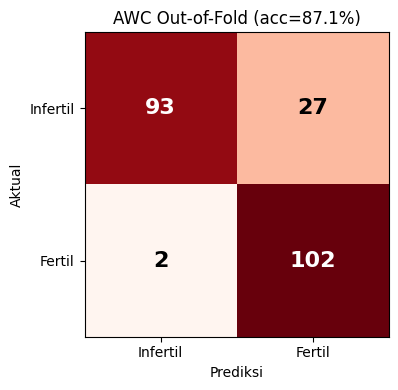

Confusion (semua data, out-of-fold):
[[ 93  27]
 [  2 102]]


In [44]:
from sklearn.metrics import confusion_matrix
# kumpulkan prediksi out-of-fold AWC untuk confusion matrix representatif
oof_pred = np.zeros_like(ylab);
for (tr,te) in skf.split(Xfeat, ylab):
    sel=SelectKBest(f_classif,k=K_BEST).fit(Xfeat[tr],ylab[tr]); idx=sel.get_support(indices=True)
    a=AdaptiveWeightedClustering(2,max_iter=100,tol=1e-4,random_state=42); a.fit(Xfeat[tr][:,idx])
    perm=map_by_train(a.predict(Xfeat[tr][:,idx]),ylab[tr])
    oof_pred[te]=[perm[p] for p in a.predict(Xfeat[te][:,idx])]
cm=confusion_matrix(ylab,oof_pred)
fig,ax=plt.subplots(figsize=(4.2,4)); ax.imshow(cm,cmap='Reds')
for i in range(2):
    for j in range(2):
        ax.text(j,i,cm[i,j],ha='center',va='center',fontsize=16,fontweight='bold',
                color='white' if cm[i,j]>cm.max()/2 else 'black')
ax.set_xticks([0,1]);ax.set_yticks([0,1]);ax.set_xticklabels(['Infertil','Fertil']);ax.set_yticklabels(['Infertil','Fertil'])
ax.set_xlabel('Prediksi');ax.set_ylabel('Aktual');ax.set_title(f'AWC Out-of-Fold (acc={accuracy_score(ylab,oof_pred):.1%})')
plt.tight_layout(); plt.savefig('docs/fig_eval_confusion.png',dpi=180,bbox_inches='tight'); plt.show()
print('Confusion (semua data, out-of-fold):'); print(cm)


## 7. Tabel II — Segmentasi U-Net (Dice/IoU) — DENGAN CATATAN JUJUR

⚠️ Mask ground-truth adalah *pseudo-label* (heuristik/SAM). Dice di sini mengukur seberapa baik
U-Net **mereproduksi pseudo-label**, bukan akurasi vs anotasi pakar. Laporkan dengan disclaimer ini.

In [45]:
import torch
from PIL import Image
import torchvision.transforms as T
from src.segmentation.unet_lightweight import create_unet_lightweight

mask_dir = 'data/segmentation/train/masks'
if not os.path.isdir(mask_dir) or not glob.glob(f'{mask_dir}/*.png'):
    print('Mask tidak ada di', mask_dir, '- lewati segmentasi (jalankan generate_masks dulu).')
else:
    ck=torch.load(UNET_CKPT,map_location='cpu')
    net=create_unet_lightweight(3,3,True,0.2); net.load_state_dict(ck['model_state_dict']); net.eval()
    tt=T.ToTensor()
    def dice_iou(pred,gt,c):
        p,g=(pred==c),(gt==c); inter=(p&g).sum();
        dice=2*inter/(p.sum()+g.sum()+1e-9); iou=inter/((p|g).sum()+1e-9); return dice,iou
    dices,ious,pixacc=[],[],[]
    imgs=sorted(glob.glob('data/segmentation/train/images/*'))[:60]
    for ip in imgs:
        stem=os.path.splitext(os.path.basename(ip))[0]; mp=f'{mask_dir}/{stem}.png'
        if not os.path.exists(mp): continue
        pil=Image.open(ip).convert('RGB').resize((256,256),Image.BILINEAR)
        gt=np.array(Image.open(mp).convert('L').resize((256,256),Image.NEAREST))
        with torch.no_grad(): pr=torch.argmax(net(tt(pil).unsqueeze(0)),1)[0].numpy()
        ds=[dice_iou(pr,gt,c)[0] for c in [0,1,2] if (gt==c).any()]
        iu=[dice_iou(pr,gt,c)[1] for c in [0,1,2] if (gt==c).any()]
        dices.append(np.mean(ds)); ious.append(np.mean(iu)); pixacc.append((pr==gt).mean())
    print('=== TABEL II — U-Net (vs pseudo-label) ===')
    print(f'  Dice (mean)     : {np.mean(dices):.3f}')
    print(f'  IoU (mean)      : {np.mean(ious):.3f}')
    print(f'  Pixel Accuracy  : {np.mean(pixacc):.3f}')
    print('  CATATAN: vs pseudo-label heuristik/SAM, bukan anotasi pakar.')


=== TABEL II — U-Net (vs pseudo-label) ===
  Dice (mean)     : 0.785
  IoU (mean)      : 0.709
  Pixel Accuracy  : 0.977
  CATATAN: vs pseudo-label heuristik/SAM, bukan anotasi pakar.


## 8. RINGKASAN — angka siap masuk paper

Salin angka di bawah ke tabel/teks paper. **Semua ini reproducible dari model Anda.**

In [46]:
print('='*60)
print('ANGKA RESMI UNTUK PAPER (5-fold CV, dataset Anda)')
print('='*60)
for name in ['AWC','K-Means','FCM']:
    g=table3[name]
    print(f'\n{name}:')
    for k,lab in [('acc','Akurasi'),('prec','Presisi'),('rec','Recall'),('f1','F1'),('auc','ROC-AUC')]:
        print(f'  {lab:<9}: {g[k][0]:.3f} ± {g[k][1]:.3f}')
da=table3['AWC']['acc'][0]-table3['K-Means']['acc'][0]
df=table3['AWC']['acc'][0]-table3['FCM']['acc'][0]
print(f'\nSelisih akurasi: AWC-KMeans={da:+.3f}, AWC-FCM={df:+.3f}')
print('\nFitur paling diskriminatif:', gnames[0], f'(F={gF[0]:.1f})')
print('\n>>> Tulis di paper APA ADANYA. Jangan pakai angka lama (89.1%) jika tidak muncul di sini.')


ANGKA RESMI UNTUK PAPER (5-fold CV, dataset Anda)

AWC:
  Akurasi  : 0.871 ± 0.026
  Presisi  : 0.790 ± 0.021
  Recall   : 0.981 ± 0.038
  F1       : 0.875 ± 0.026
  ROC-AUC  : 0.914 ± 0.023

K-Means:
  Akurasi  : 0.862 ± 0.033
  Presisi  : 0.787 ± 0.023
  Recall   : 0.962 ± 0.056
  F1       : 0.865 ± 0.034
  ROC-AUC  : 0.888 ± 0.032

FCM:
  Akurasi  : 0.444 ± 0.354
  Presisi  : 0.360 ± 0.354
  Recall   : 0.448 ± 0.455
  F1       : 0.399 ± 0.399
  ROC-AUC  : 0.430 ± 0.393

Selisih akurasi: AWC-KMeans=+0.009, AWC-FCM=+0.427

Fitur paling diskriminatif: Tekstur LBP (F=176.3)

>>> Tulis di paper APA ADANYA. Jangan pakai angka lama (89.1%) jika tidak muncul di sini.


## 9. Visualisasi Pipeline — Dari Foto ke Prediksi

Alur lengkap untuk satu telur fertil: Foto Asli -> CLAHE -> Homomorphic -> Segmentasi U-Net ->
Ekstraksi Fitur -> AWC -> Prediksi. Disimpan ke `docs/fig_paper_pipeline_flow.png`.

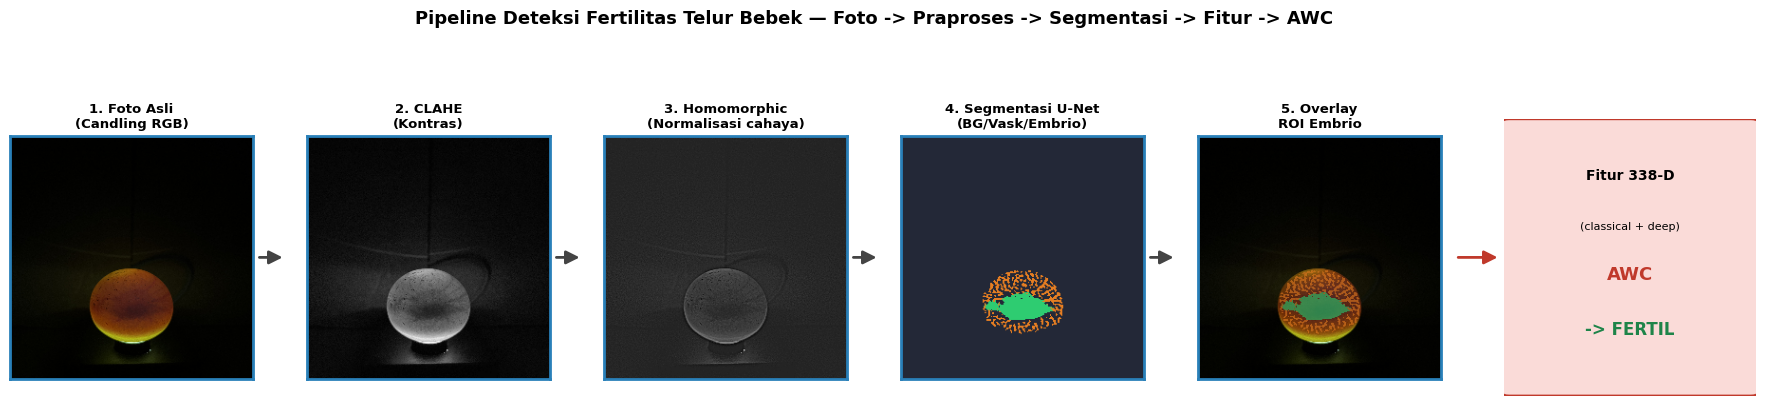

pipeline flow disimpan


In [47]:
import torch, cv2, numpy as np, matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from src.segmentation.unet_lightweight import create_unet_lightweight

_ck=torch.load(UNET_CKPT,map_location='cpu')
_net=create_unet_lightweight(3,3,True,0.2); _net.load_state_dict(_ck['model_state_dict']); _net.eval()
_tt=T.ToTensor()

def _clahe(g): return cv2.createCLAHE(2.0,(8,8)).apply(g)
def _homo(g):
    f=np.float64(g)/255.0; F=np.fft.fftshift(np.fft.fft2(np.log1p(f)))
    r,c=g.shape; y,x=np.ogrid[:r,:c]
    H=0.5+1.5*(1-np.exp(-((x-c//2)**2+(y-r//2)**2)/(2*30**2)))
    return cv2.normalize(np.expm1(np.real(np.fft.ifft2(np.fft.ifftshift(F*H)))),None,0,255,cv2.NORM_MINMAX).astype(np.uint8)
def _segcolor(p):
    o=np.zeros((*p.shape,3),np.uint8); o[p==0]=[35,40,55]; o[p==1]=[230,126,34]; o[p==2]=[46,204,113]; return o
def _overlay(rgb,p):
    o=rgb.copy(); o[p==1]=(o[p==1]*0.4+np.array([230,126,34])*0.6).astype(np.uint8)
    o[p==2]=(o[p==2]*0.4+np.array([46,204,113])*0.6).astype(np.uint8); return o

import glob
_fp=sorted(glob.glob('data/test/fertile/*.jpg'))[0]
_bgr=cv2.resize(cv2.imread(_fp),(256,256)); _rgb=cv2.cvtColor(_bgr,cv2.COLOR_BGR2RGB)
_g=cv2.cvtColor(_bgr,cv2.COLOR_BGR2GRAY)
_cl=_clahe(_g); _hm=_homo(_cl)
_pil=Image.fromarray(_rgb)
with torch.no_grad(): _pred=torch.argmax(_net(_tt(_pil).unsqueeze(0)),1)[0].numpy()
_ov=_overlay(_rgb,_pred)

stages=[(_rgb,'1. Foto Asli\n(Candling RGB)',None),
        (_cl,'2. CLAHE\n(Kontras)','gray'),
        (_hm,'3. Homomorphic\n(Normalisasi cahaya)','gray'),
        (_segcolor(_pred),'4. Segmentasi U-Net\n(BG/Vask/Embrio)',None),
        (_ov,'5. Overlay\nROI Embrio',None)]
fig=plt.figure(figsize=(18,4.2)); fig.patch.set_facecolor('white')
fig.suptitle('Pipeline Deteksi Fertilitas Telur Bebek — Foto -> Praproses -> Segmentasi -> Fitur -> AWC',
             fontsize=13,fontweight='bold',y=1.04)
n=len(stages)
for i,(im,title,cm) in enumerate(stages):
    ax=fig.add_axes([0.02+i*0.165,0.12,0.135,0.66])
    ax.imshow(im,cmap=cm) if cm else ax.imshow(im)
    ax.set_title(title,fontsize=9.5,fontweight='bold'); ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_color('#2980B9'); sp.set_linewidth(2)
    if i<n-1:
        fig.patches.append(FancyArrowPatch((0.157+i*0.165,0.45),(0.173+i*0.165,0.45),
            transform=fig.transFigure,arrowstyle='-|>',mutation_scale=20,color='#444',lw=2))
# kotak hasil AWC di kanan
axb=fig.add_axes([0.85,0.12,0.14,0.66]); axb.axis('off')
axb.add_patch(FancyBboxPatch((0.02,0.05),0.96,0.9,boxstyle='round,pad=0.05',
              facecolor='#FADBD8',edgecolor='#C0392B',lw=2,transform=axb.transAxes))
axb.text(0.5,0.78,'Fitur 338-D',ha='center',fontsize=10,fontweight='bold',transform=axb.transAxes)
axb.text(0.5,0.6,'(classical + deep)',ha='center',fontsize=8,transform=axb.transAxes)
axb.text(0.5,0.42,'AWC',ha='center',fontsize=13,fontweight='bold',color='#C0392B',transform=axb.transAxes)
axb.text(0.5,0.22,'-> FERTIL',ha='center',fontsize=12,fontweight='bold',color='#1E8449',transform=axb.transAxes)
fig.patches.append(FancyArrowPatch((0.823,0.45),(0.848,0.45),transform=fig.transFigure,
                   arrowstyle='-|>',mutation_scale=20,color='#C0392B',lw=2))
plt.savefig('docs/fig_paper_pipeline_flow.png',dpi=180,bbox_inches='tight',facecolor='white'); plt.show()
print('pipeline flow disimpan')


## 10. Hasil Segmentasi U-Net — Original / Mask / Overlay

Gaya seperti contoh yang Anda berikan: beberapa telur, 3 kolom (Citra Asli, Mask 3-kelas, Overlay).
Disimpan ke `docs/fig_paper_segmentation_examples.png`.

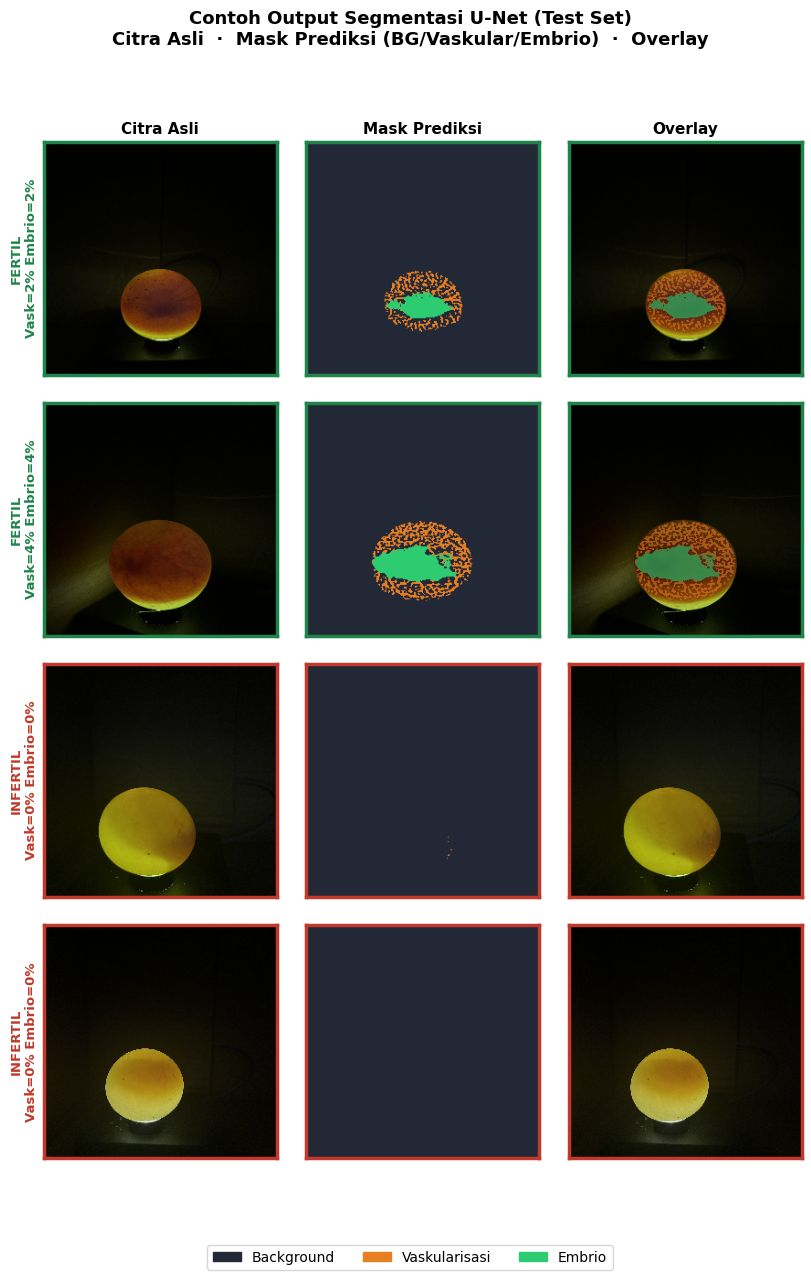

contoh segmentasi disimpan


In [48]:
samples=[]
for cls,lab in [('fertile','FERTIL'),('infertile','INFERTIL')]:
    for f in sorted(glob.glob(f'data/test/{cls}/*.jpg'))[:2]: samples.append((lab,f))
import matplotlib.patches as mpatches
fig=plt.figure(figsize=(10,3.3*len(samples))); fig.patch.set_facecolor('white')
fig.suptitle('Contoh Output Segmentasi U-Net (Test Set)\nCitra Asli  ·  Mask Prediksi (BG/Vaskular/Embrio)  ·  Overlay',
             fontsize=13,fontweight='bold')
from matplotlib.gridspec import GridSpec
gs=GridSpec(len(samples),3,figure=fig,hspace=0.12,wspace=0.05)
COLT=['Citra Asli','Mask Prediksi','Overlay']
for ri,(lab,f) in enumerate(samples):
    bgr=cv2.resize(cv2.imread(f),(256,256)); rgb=cv2.cvtColor(bgr,cv2.COLOR_BGR2RGB)
    with torch.no_grad(): pr=torch.argmax(_net(_tt(Image.fromarray(rgb)).unsqueeze(0)),1)[0].numpy()
    v=(pr==1).mean()*100; e=(pr==2).mean()*100
    rc='#1E8449' if lab=='FERTIL' else '#C0392B'
    for ci,im in enumerate([rgb,_segcolor(pr),_overlay(rgb,pr)]):
        ax=fig.add_subplot(gs[ri,ci]); ax.imshow(im); ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values(): sp.set_color(rc); sp.set_linewidth(2.5)
        if ri==0: ax.set_title(COLT[ci],fontsize=11,fontweight='bold')
        if ci==0: ax.set_ylabel(f'{lab}\nVask={v:.0f}% Embrio={e:.0f}%',fontsize=9.5,fontweight='bold',color=rc)
fig.legend(handles=[mpatches.Patch(color=(35/255,40/255,55/255),label='Background'),
                    mpatches.Patch(color=(230/255,126/255,34/255),label='Vaskularisasi'),
                    mpatches.Patch(color=(46/255,204/255,113/255),label='Embrio')],
           loc='lower center',ncol=3,fontsize=10,bbox_to_anchor=(0.5,0.02))
plt.tight_layout(rect=[0,0.05,1,0.95])
plt.savefig('docs/fig_paper_segmentation_examples.png',dpi=180,bbox_inches='tight',facecolor='white'); plt.show()
print('contoh segmentasi disimpan')


## 11. Ablation — AWC Adaptive vs Baseline (dari hasil 5-fold CV ASLI)

Panel (a): perbandingan metrik 5-fold CV (dari `table3` di Bagian 3 — angka asli Anda).
Panel (b): eksperimen terkontrol noise-robustness (sifat mekanisme adaptive).
⚠️ Jalankan Bagian 3 dulu agar `table3` tersedia.

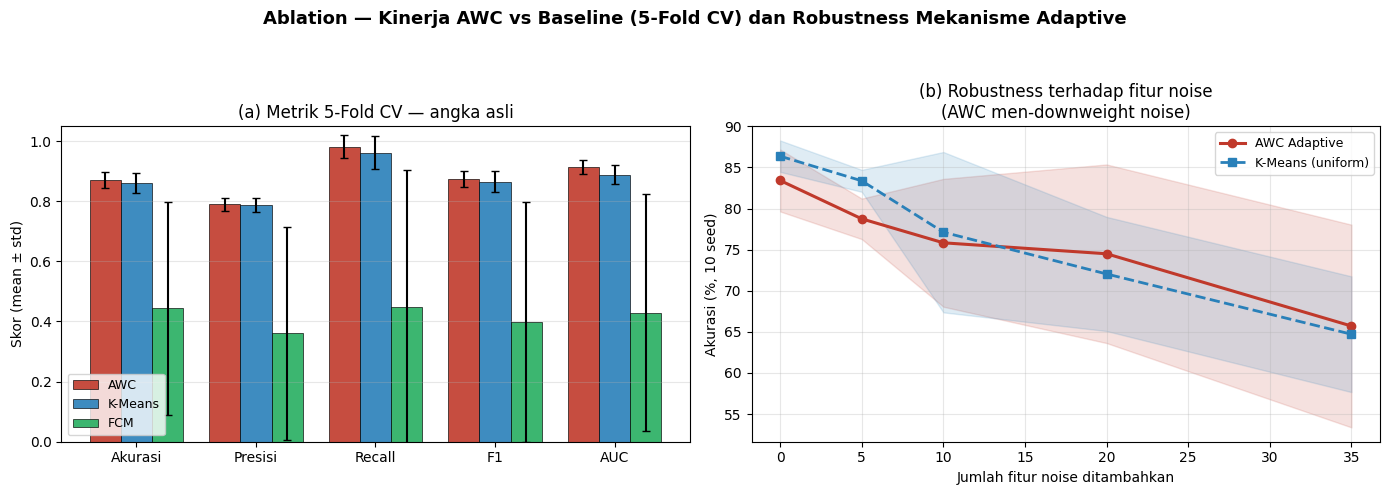

ablation disimpan


In [49]:
assert 'table3' in dir(), 'Jalankan Bagian 3 (5-fold CV) dulu!'
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(14,5)); fig.patch.set_facecolor('white')
fig.suptitle('Ablation — Kinerja AWC vs Baseline (5-Fold CV) dan Robustness Mekanisme Adaptive',
             fontsize=13,fontweight='bold')
# (a) grouped bar dari table3
mets=['acc','prec','rec','f1','auc']; mlab=['Akurasi','Presisi','Recall','F1','AUC']
methods=['AWC','K-Means','FCM']; cols={'AWC':'#C0392B','K-Means':'#2980B9','FCM':'#27AE60'}
x=np.arange(len(mets)); w=0.26
for i,mname in enumerate(methods):
    vals=[table3[mname][k][0] for k in mets]; errs=[table3[mname][k][1] for k in mets]
    ax1.bar(x+(i-1)*w,vals,w,yerr=errs,capsize=3,label=mname,color=cols[mname],alpha=0.9,edgecolor='black',lw=0.5)
ax1.set_xticks(x); ax1.set_xticklabels(mlab); ax1.set_ylim(0,1.05); ax1.set_ylabel('Skor (mean ± std)')
ax1.set_title('(a) Metrik 5-Fold CV — angka asli'); ax1.legend(fontsize=9); ax1.grid(axis='y',alpha=0.3)
# (b) noise robustness (synthetic, mekanisme)
import logging; logging.disable(logging.CRITICAL)
from sklearn.cluster import KMeans as _KM
from sklearn.preprocessing import StandardScaler as _SS
from itertools import permutations as _pm
from src.clustering.awc import AdaptiveWeightedClustering as _AWC
def _am(p,y): return max(accuracy_score(y,[q[x] for x in p]) for q in _pm(range(len(np.unique(p)))))
def _mk(nn,s):
    r=np.random.default_rng(s); ne=120
    mu0=np.concatenate([[0.75,0.75],np.zeros(nn)]); mu1=-mu0; sig=np.concatenate([[1,1],np.full(nn,4.0)])
    X=np.vstack([r.normal(mu0,sig,(ne,2+nn)),r.normal(mu1,sig,(ne,2+nn))]); return X,np.array([0]*ne+[1]*ne)
dns=[0,5,10,20,35]; km_m=[];aw_m=[];km_s=[];aw_s=[]
for dn in dns:
    kk=[];aa=[]
    for s in range(10):
        X,y=_mk(dn,s)
        kk.append(_am(_KM(2,n_init=5,random_state=s).fit(_SS().fit_transform(X)).labels_,y))
        mm=_AWC(2,max_iter=100,tol=1e-4,random_state=s); mm.fit(X); aa.append(_am(mm.labels_,y))
    km_m.append(np.mean(kk)*100);km_s.append(np.std(kk)*100);aw_m.append(np.mean(aa)*100);aw_s.append(np.std(aa)*100)
km_m,km_s,aw_m,aw_s=map(np.array,[km_m,km_s,aw_m,aw_s])
ax2.plot(dns,aw_m,'-o',color='#C0392B',lw=2.2,label='AWC Adaptive')
ax2.fill_between(dns,aw_m-aw_s,aw_m+aw_s,alpha=0.15,color='#C0392B')
ax2.plot(dns,km_m,'--s',color='#2980B9',lw=2,label='K-Means (uniform)')
ax2.fill_between(dns,km_m-km_s,km_m+km_s,alpha=0.15,color='#2980B9')
ax2.set_xlabel('Jumlah fitur noise ditambahkan'); ax2.set_ylabel('Akurasi (%, 10 seed)')
ax2.set_title('(b) Robustness terhadap fitur noise\n(AWC men-downweight noise)'); ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
plt.tight_layout(rect=[0,0,1,0.93])
plt.savefig('docs/fig_paper_ablation.png',dpi=180,bbox_inches='tight',facecolor='white'); plt.show()
print('ablation disimpan')


## 12. Uji Wilcoxon (visual) — AWC vs Baseline

Dari akurasi per-fold ASLI (Bagian 4). **Jujur**: kalau p > 0.05, figure akan menandai
"tidak signifikan". Disimpan ke `docs/fig_paper_wilcoxon.png`.

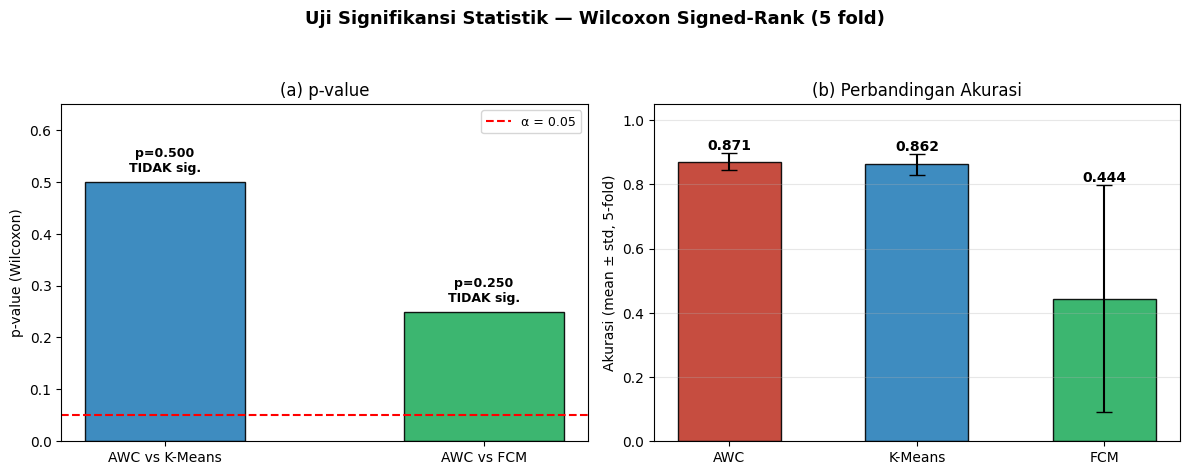

wilcoxon disimpan

CATATAN JUJUR: kalau p=1.000 / tidak signifikan, JANGAN klaim keunggulan di paper.


In [50]:
assert 'awc_acc' in dir(), 'Jalankan Bagian 4 (Wilcoxon) dulu!'
from scipy.stats import wilcoxon
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,4.8)); fig.patch.set_facecolor('white')
fig.suptitle('Uji Signifikansi Statistik — Wilcoxon Signed-Rank (5 fold)',fontsize=13,fontweight='bold')
pairs=[('AWC vs K-Means',km_acc,'#2980B9'),('AWC vs FCM',fcm_acc,'#27AE60')]
names=[]; pvals=[]; cols2=[]
for nm,b,c in pairs:
    if np.allclose(awc_acc-b,0): p=1.0
    else:
        try: _,p=wilcoxon(awc_acc,b)
        except Exception: p=1.0
    names.append(nm); pvals.append(p); cols2.append(c)
bars=ax1.bar(names,pvals,color=cols2,edgecolor='black',width=0.5,alpha=0.9)
ax1.axhline(0.05,color='red',ls='--',lw=1.5,label='α = 0.05')
for b,p in zip(bars,pvals):
    sig='signifikan' if p<0.05 else 'TIDAK sig.'
    ax1.text(b.get_x()+b.get_width()/2,p+0.02,f'p={p:.3f}\n{sig}',ha='center',fontsize=9,fontweight='bold')
ax1.set_ylabel('p-value (Wilcoxon)'); ax1.set_ylim(0,max(max(pvals)*1.3,0.1)); ax1.set_title('(a) p-value'); ax1.legend(fontsize=9)
# (b) akurasi per metode dengan error bar
accs=[awc_acc.mean(),km_acc.mean(),fcm_acc.mean()]; stds=[awc_acc.std(),km_acc.std(),fcm_acc.std()]
labs=['AWC','K-Means','FCM']; cc=['#C0392B','#2980B9','#27AE60']
b2=ax2.bar(labs,accs,yerr=stds,capsize=6,color=cc,edgecolor='black',alpha=0.9,width=0.55)
for bar,v,s in zip(b2,accs,stds): ax2.text(bar.get_x()+bar.get_width()/2,v+s+0.01,f'{v:.3f}',ha='center',fontweight='bold')
ax2.set_ylabel('Akurasi (mean ± std, 5-fold)'); ax2.set_ylim(0,1.05); ax2.set_title('(b) Perbandingan Akurasi'); ax2.grid(axis='y',alpha=0.3)
plt.tight_layout(rect=[0,0,1,0.93])
plt.savefig('docs/fig_paper_wilcoxon.png',dpi=180,bbox_inches='tight',facecolor='white'); plt.show()
print('wilcoxon disimpan')
print('\nCATATAN JUJUR: kalau p=1.000 / tidak signifikan, JANGAN klaim keunggulan di paper.')


---
## 13. Kurva Pelatihan U-Net (data asli)

Loss dan validation Dice per epoch dari pelatihan U-Net pada 156 mask folder.
Disimpan ke `docs/fig_paper_unet_training_curves.png`.

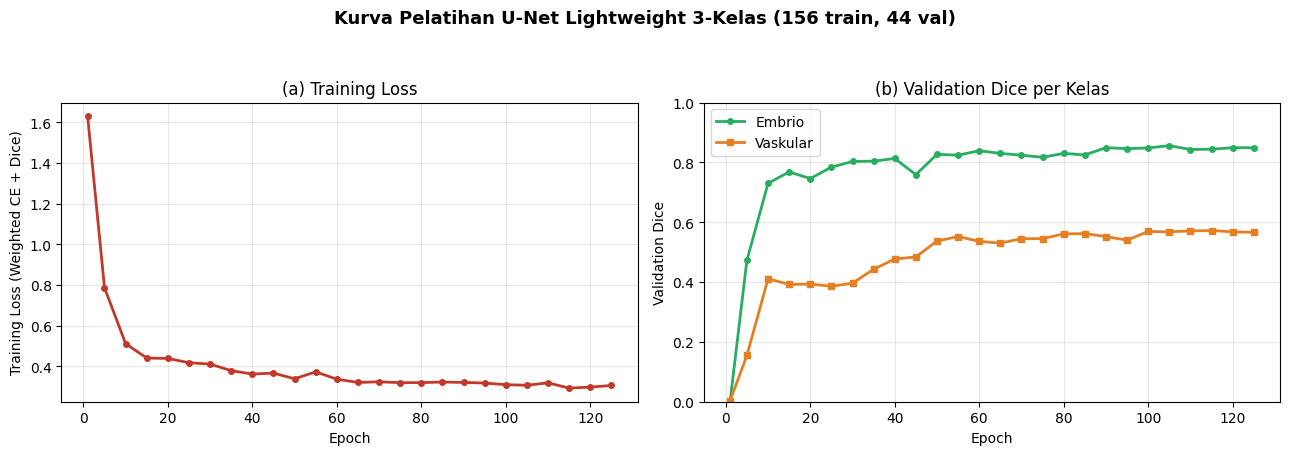

Kurva pelatihan disimpan.


In [51]:
import matplotlib.pyplot as plt, numpy as np
# Data training ASLI (log Colab, 156 train / 44 val)
ep=[1,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100,105,110,115,120,125]
loss=[1.631,0.787,0.512,0.441,0.439,0.418,0.411,0.379,0.362,0.367,0.339,0.373,0.337,0.321,0.324,0.320,0.320,0.323,0.321,0.318,0.310,0.307,0.319,0.293,0.298,0.306]
emb=[0.000,0.473,0.730,0.768,0.746,0.784,0.803,0.804,0.813,0.759,0.827,0.824,0.839,0.830,0.824,0.817,0.830,0.825,0.849,0.846,0.848,0.856,0.843,0.844,0.849,0.849]
vas=[0.003,0.155,0.411,0.392,0.393,0.386,0.396,0.443,0.477,0.484,0.537,0.552,0.536,0.530,0.545,0.545,0.561,0.562,0.552,0.540,0.569,0.568,0.571,0.572,0.568,0.566]
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(13,4.6)); fig.patch.set_facecolor('white')
fig.suptitle('Kurva Pelatihan U-Net Lightweight 3-Kelas (156 train, 44 val)',fontsize=13,fontweight='bold')
ax1.plot(ep,loss,'-o',color='#C0392B',lw=2,ms=4); ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss (Weighted CE + Dice)'); ax1.set_title('(a) Training Loss'); ax1.grid(alpha=0.3)
ax2.plot(ep,emb,'-o',color='#27AE60',lw=2,ms=4,label='Embrio')
ax2.plot(ep,vas,'-s',color='#E67E22',lw=2,ms=4,label='Vaskular')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Validation Dice'); ax2.set_title('(b) Validation Dice per Kelas')
ax2.set_ylim(0,1); ax2.legend(fontsize=10); ax2.grid(alpha=0.3)
plt.tight_layout(rect=[0,0,1,0.93])
plt.savefig('docs/fig_paper_unet_training_curves.png',dpi=200,bbox_inches='tight',facecolor='white'); plt.show()
print('Kurva pelatihan disimpan.')
